# Connect Google Drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import torch
print(f"Is CUDA available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Is CUDA available? True
GPU Name: NVIDIA L4


# Install **pytorch-tabnet, optuna**

In [ ]:
!pip install pytorch-tabnet optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 42.6 MB/s eta 0:00:00


# Important Libraries

In [ ]:
import torch
import shap
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from sklearn.utils.class_weight import compute_class_weight
from pytorch_tabnet.metrics import Metric
from pytorch_tabnet.tab_model import TabNetClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report
import joblib
import os
import gc

# Sentinel-2

## Data Loading


In [ ]:
s2_file_path = "/content/drive/MyDrive/Thesis/Train_data/s2_with_veg_data.csv"

print("Loading data...")
s2df = pd.read_csv(s2_file_path)
print("Data is loaded")

print("\nData preparation...")
s2df.drop(columns=["height", "stock_per_ha", "basal_area", "poly_id", "S2_Date"], axis=1, inplace=True)

s2df1 = s2df.loc[s2df["age"] != 5]

s2_y = s2df1["age"]-1
S2_X = s2df1.drop(columns=["age"], axis=1)

S2_train, S2_val, s2_train, s2_val = train_test_split(S2_X, s2_y, test_size=0.15, random_state=42, stratify=s2_y)
S2_train, S2_test, s2_train, s2_test = train_test_split(S2_train, s2_train, test_size=0.15, random_state=42, stratify=s2_train)

print(f"\nDatasets are read! S2_train shape: {S2_train.shape}, S2_test shape: {S2_test.shape}, S2_val shape: {S2_val.shape}")

Loading data...
Data is loaded

Data preparation...

Datasets are read! S2_train shape: (284286, 52), S2_test shape: (50169, 52), S2_val shape: (59022, 52)


## Training with optimized Hyper-parameters


### XGBoost Model Training, Evaluation and Plot

In [ ]:
ros = RandomOverSampler(sampling_strategy='auto')
S2_resampled, s2_resampled = ros.fit_resample(S2_train, s2_train)


Starting XGBoost training...
[0]	validation_0-mlogloss:1.37374
[1]	validation_0-mlogloss:1.36219
[2]	validation_0-mlogloss:1.35132
[3]	validation_0-mlogloss:1.34111
[4]	validation_0-mlogloss:1.33150
[5]	validation_0-mlogloss:1.32223
[6]	validation_0-mlogloss:1.31352
[7]	validation_0-mlogloss:1.30547
[8]	validation_0-mlogloss:1.29743
[9]	validation_0-mlogloss:1.28986
[10]	validation_0-mlogloss:1.28252
[11]	validation_0-mlogloss:1.27606
[12]	validation_0-mlogloss:1.26956
[13]	validation_0-mlogloss:1.26343
[14]	validation_0-mlogloss:1.25764
[15]	validation_0-mlogloss:1.25199
[16]	validation_0-mlogloss:1.24653
[17]	validation_0-mlogloss:1.24151
[18]	validation_0-mlogloss:1.23659
[19]	validation_0-mlogloss:1.23177
[20]	validation_0-mlogloss:1.22721
[21]	validation_0-mlogloss:1.22275
[22]	validation_0-mlogloss:1.21854
[23]	validation_0-mlogloss:1.21464
[24]	validation_0-mlogloss:1.21067
[25]	validation_0-mlogloss:1.20674
[26]	validation_0-mlogloss:1.20307
[27]	validation_0-mlogloss:1.19935


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [06:20:37] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



XGBClassifier Classification Report
              precision    recall  f1-score   support

         0.0       0.42      0.42      0.42      4412
         1.0       0.76      0.76      0.76     30858
         2.0       0.33      0.30      0.31      7238
         3.0       0.47      0.51      0.49      7661

    accuracy                           0.63     50169
   macro avg       0.49      0.50      0.50     50169
weighted avg       0.62      0.63      0.62     50169



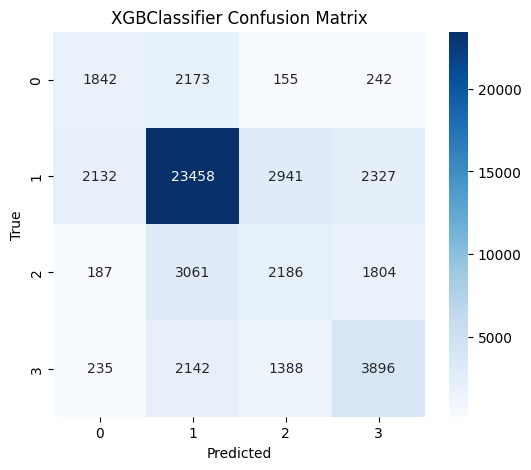

In [ ]:
print("\nStarting XGBoost training...")
# #Best Parameters XGB:
#  {'classifier__subsample': 0.6,
# 'classifier__n_estimators': 1000,
# 'classifier__min_child_weight': 7,
# 'classifier__max_depth': 11,
# 'classifier__learning_rate': 0.05,
# 'classifier__gamma': 1.0,
# 'classifier__colsample_bytree': 0.8}

XGBmodel_age = XGBClassifier(
    n_estimators=1000,
    max_depth = 11,
    learning_rate = 0.05,
    colsample_bytree = 0.8,
    subsample = 0.6,
    min_child_weight = 7,
    gamma = 1.0,
    device="cuda",
    early_stopping_rounds=50
)

XGBmodel_age.fit(
    S2_resampled, s2_resampled,
    eval_set=[(S2_val, s2_val)]
)
print("XGBoost Training finished")

# Evaluation
print("\nEvaluating models on Test Set...")
xgb_pred = XGBmodel_age.predict(S2_test)

print("\nXGBClassifier Classification Report")
print(classification_report(s2_test, xgb_pred))

# Plot Confusion Matrices
plt.figure(figsize=(6, 5))
cm_xgb = confusion_matrix(s2_test, xgb_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues')
plt.title("XGBClassifier Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

### Tabnet Model Training, Evaluation and Plot

In [ ]:
print("Calculating Smoothed Class Weights...")

unique_classes = np.unique(s2_train)

standard_class_weights = compute_class_weight('balanced', classes=unique_classes, y=s2_train)

smoothed_class_weights = np.sqrt(standard_class_weights)

smoothed_weight_dict = {
    int(class_label): float(weight)
    for class_label, weight in zip(unique_classes, smoothed_class_weights)
}

print("Smoothed Weights Dictionary:", smoothed_weight_dict)

Calculating Smoothed Class Weights...
Smoothed Weights Dictionary: {0: 1.6860445694430484, 1: 0.6375345794450832, 2: 1.3163812181075647, 3: 1.279507522681642}


In [ ]:
S2_train_np = S2_train.values.astype(np.float32) if isinstance(S2_train, pd.DataFrame) else S2_train.astype(np.float32)
s2_train_np = s2_train.values.astype(int) if isinstance(s2_train, pd.Series) else s2_train.astype(int)

S2_val_np = S2_val.values.astype(np.float32) if isinstance(S2_val, pd.DataFrame) else S2_val.astype(np.float32)
s2_val_np = s2_val.values.astype(int) if isinstance(s2_val, pd.Series) else s2_val.astype(int)

S2_test_np = S2_test.values.astype(np.float32) if isinstance(S2_test, pd.DataFrame) else S2_test.astype(np.float32)
s2_test_np = s2_test.values.astype(int) if isinstance(s2_test, pd.Series) else s2_test.astype(int)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.48961 | valid_logloss: 1.10717 |  0:00:24s
epoch 1  | loss: 1.21675 | valid_logloss: 1.09827 |  0:00:48s
epoch 2  | loss: 1.2075  | valid_logloss: 1.066   |  0:01:11s
epoch 3  | loss: 1.19833 | valid_logloss: 1.04694 |  0:01:35s
epoch 4  | loss: 1.18038 | valid_logloss: 1.06332 |  0:01:58s
epoch 5  | loss: 1.17318 | valid_logloss: 1.04921 |  0:02:21s
epoch 6  | loss: 1.17458 | valid_logloss: 1.04985 |  0:02:45s
epoch 7  | loss: 1.16192 | valid_logloss: 1.0481  |  0:03:09s
epoch 8  | loss: 1.14791 | valid_logloss: 1.01123 |  0:03:33s
epoch 9  | loss: 1.14161 | valid_logloss: 1.03513 |  0:03:56s
epoch 10 | loss: 1.12916 | valid_logloss: 1.03124 |  0:04:20s
epoch 11 | loss: 1.12599 | valid_logloss: 1.00836 |  0:04:43s
epoch 12 | loss: 1.11591 | valid_logloss: 0.97426 |  0:05:07s
epoch 13 | loss: 1.11228 | valid_logloss: 1.00589 |  0:05:31s
epoch 14 | loss: 1.11209 | valid_logloss: 0.9989  |  0:05:54s
epoch 15 | loss: 1.11286 | valid_logloss: 0.99584 |  0:06:18s
epoch 16

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Evaluating TabNet Model on Test Set...

--- TabNet Classification Report ---
              precision    recall  f1-score   support

           0       0.41      0.47      0.44      4412
           1       0.76      0.77      0.77     30858
           2       0.34      0.32      0.33      7238
           3       0.51      0.48      0.49      7661

    accuracy                           0.63     50169
   macro avg       0.51      0.51      0.51     50169
weighted avg       0.63      0.63      0.63     50169



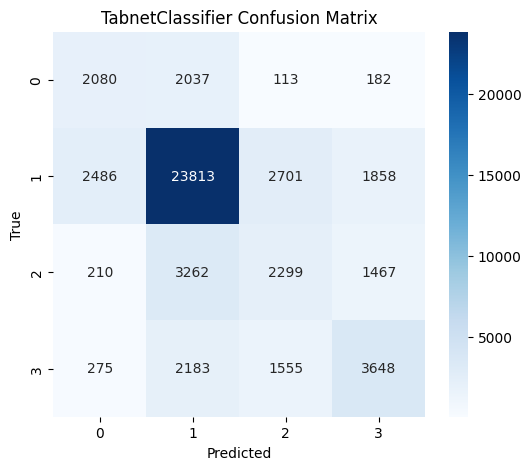

In [ ]:
# Best TabNet Parameters Found:
#   n_d: 64
#   n_steps: 7
#   gamma: 1.6627277981428936
#   lambda_sparse: 0.0024679054940156702
#   lr: 0.006594489269960494


Tabnet_age = TabNetClassifier(
    n_d= 64,
    n_a= 64,
    n_steps= 7,
    gamma= 1.6627277981428936,
    lambda_sparse= 0.0024679054940156702,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.006594489269960494),
    mask_type='entmax',
    device_name='cuda',
    verbose=1
)

Tabnet_age.fit(
    X_train=S2_train_np, y_train=s2_train_np,
    eval_set=[(S2_val_np, s2_val_np)],
    eval_name=['valid'],
    eval_metric=['logloss'],
    max_epochs=150,
    patience=20,
    batch_size=1024, virtual_batch_size=128,
    weights=smoothed_weight_dict
)

print("\nEvaluating TabNet Model on Test Set...")
tabnet_preds = Tabnet_age.predict(S2_test_np)

print("\n--- TabNet Classification Report ---")
print(classification_report(s2_test_np, tabnet_preds))

# Plot Confusion Matrices side-by-side
plt.figure(figsize=(6, 5))
cm_xgb = confusion_matrix(s2_test_np, tabnet_preds)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues')
plt.title("TabnetClassifier Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Alpha Earth Foundation + Sentinel-2

## Data Loading

In [ ]:
aef_file_path = "/content/drive/MyDrive/Thesis/Train_data/s2_aef_with_veg_data.csv"

print("Loading data...")
aefdf = pd.read_csv(aef_file_path)
print("Data is loaded")

print("\nData preparation...")
aefdf.drop(columns=["height", "stock_per_ha", "basal_area", "poly_id", "S2_Date"], axis=1, inplace=True)

aefdf1 = aefdf.loc[aefdf["age"] != 5].dropna()

aef_y = aefdf1["age"]-1
AEF_X = aefdf1.drop(columns=["age"], axis=1)

AEF_train, AEF_val, aef_train, aef_val = train_test_split(AEF_X, aef_y, test_size=0.15, random_state=42, stratify=aef_y)
AEF_train, AEF_test, aef_train, aef_test = train_test_split(AEF_train, aef_train, test_size=0.15, random_state=42, stratify=aef_train)

print(f"\nDatasets are read! AEF_train shape: {AEF_train.shape}, AEF_test shape: {AEF_test.shape}, AEF_val shape: {AEF_val.shape}")

Loading data...
Data is loaded

Data preparation...

Datasets are read! AEF_train shape: (284117, 308), AEF_test shape: (50139, 308), AEF_val shape: (58987, 308)


##Training with optimized Hyper-parameters

### XGBoost Model Training, Evaluation and Plot

In [ ]:
ros = RandomOverSampler(sampling_strategy='auto')
AEF_resampled, aef_resampled = ros.fit_resample(AEF_train, aef_train)


Starting XGBoost training...
[0]	validation_0-mlogloss:1.32550
[1]	validation_0-mlogloss:1.27713
[2]	validation_0-mlogloss:1.24095
[3]	validation_0-mlogloss:1.20962
[4]	validation_0-mlogloss:1.18373
[5]	validation_0-mlogloss:1.16292
[6]	validation_0-mlogloss:1.14488
[7]	validation_0-mlogloss:1.12930
[8]	validation_0-mlogloss:1.11594
[9]	validation_0-mlogloss:1.10392
[10]	validation_0-mlogloss:1.09283
[11]	validation_0-mlogloss:1.08398
[12]	validation_0-mlogloss:1.07570
[13]	validation_0-mlogloss:1.06810
[14]	validation_0-mlogloss:1.06119
[15]	validation_0-mlogloss:1.05400
[16]	validation_0-mlogloss:1.04740
[17]	validation_0-mlogloss:1.04063
[18]	validation_0-mlogloss:1.03474
[19]	validation_0-mlogloss:1.02885
[20]	validation_0-mlogloss:1.02371
[21]	validation_0-mlogloss:1.01867
[22]	validation_0-mlogloss:1.01417
[23]	validation_0-mlogloss:1.00973
[24]	validation_0-mlogloss:1.00513
[25]	validation_0-mlogloss:1.00142
[26]	validation_0-mlogloss:0.99722
[27]	validation_0-mlogloss:0.99373


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [16:39:51] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



XGBClassifier Classification Report
              precision    recall  f1-score   support

         0.0       0.95      0.83      0.88      4410
         1.0       0.93      0.97      0.95     30848
         2.0       0.92      0.80      0.86      7230
         3.0       0.90      0.88      0.89      7651

    accuracy                           0.92     50139
   macro avg       0.92      0.87      0.89     50139
weighted avg       0.92      0.92      0.92     50139



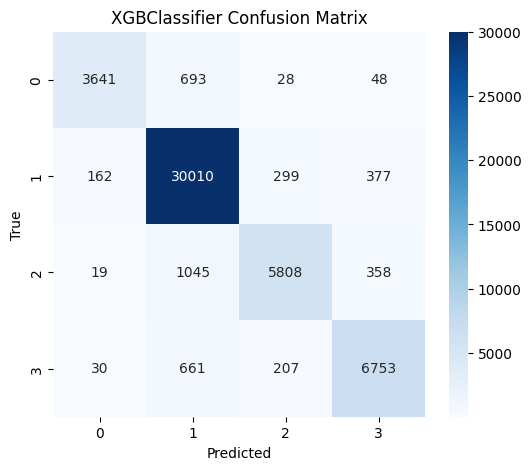

In [ ]:
print("\nStarting XGBoost training...")
# Best Parameters XGB:
#{'classifier__subsample': 0.6,
#'classifier__n_estimators': 2000,
#'classifier__min_child_weight': 1,
#'classifier__max_depth': 7,
#'classifier__learning_rate': 0.2,
#'classifier__gamma': 0,
#'classifier__colsample_bytree': 0.8}

XGBmodel_age = XGBClassifier(
    n_estimators=2000,
    max_depth = 7,
    learning_rate = 0.2,
    colsample_bytree = 0.8,
    subsample = 0.6,
    min_child_weight = 1,
    gamma = 0,
    device="cuda",
    early_stopping_rounds=50
)

XGBmodel_age.fit(
    AEF_resampled, aef_resampled,
    eval_set=[(AEF_val, aef_val)]
)
print("XGBoost Training finished")

# Evaluation
print("\nEvaluating models on Test Set...")
xgb_pred = XGBmodel_age.predict(AEF_test)

print("\nXGBClassifier Classification Report")
print(classification_report(aef_test, xgb_pred))

# Plot Confusion Matrices
plt.figure(figsize=(6, 5))
cm_xgb = confusion_matrix(aef_test, xgb_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues')
plt.title("XGBClassifier Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

### Tabnet Model Training, Evaluation and Plot

In [ ]:
print("Calculating Smoothed Class Weights...")

unique_classes = np.unique(aef_train)

standard_class_weights = compute_class_weight('balanced', classes=unique_classes, y=aef_train)

smoothed_class_weights = np.sqrt(standard_class_weights)

smoothed_weight_dict = {
    int(class_label): float(weight)
    for class_label, weight in zip(unique_classes, smoothed_class_weights)
}

print("Smoothed Weights Dictionary:", smoothed_weight_dict)

Calculating Smoothed Class Weights...
Smoothed Weights Dictionary: {0: 1.6859817367100778, 1: 0.6374489584163607, 2: 1.316680283822885, 3: 1.27995296484414}


In [ ]:
AEF_train_np = AEF_train.values.astype(np.float32) if isinstance(AEF_train, pd.DataFrame) else AEF_train.astype(np.float32)
aef_train_np = aef_train.values.astype(int) if isinstance(aef_train, pd.Series) else aef_train.astype(int)

AEF_val_np = AEF_val.values.astype(np.float32) if isinstance(AEF_val, pd.DataFrame) else AEF_val.astype(np.float32)
aef_val_np = aef_val.values.astype(int) if isinstance(aef_val, pd.Series) else aef_val.astype(int)

AEF_test_np = AEF_test.values.astype(np.float32) if isinstance(AEF_test, pd.DataFrame) else AEF_test.astype(np.float32)
aef_test_np = aef_test.values.astype(int) if isinstance(aef_test, pd.Series) else aef_test.astype(int)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.12349 | valid_logloss: 0.99591 |  0:00:15s
epoch 1  | loss: 0.95362 | valid_logloss: 0.83799 |  0:00:29s
epoch 2  | loss: 0.89028 | valid_logloss: 0.80364 |  0:00:43s
epoch 3  | loss: 0.84638 | valid_logloss: 0.76171 |  0:00:58s
epoch 4  | loss: 0.80911 | valid_logloss: 0.73155 |  0:01:12s
epoch 5  | loss: 0.76278 | valid_logloss: 0.71124 |  0:01:27s
epoch 6  | loss: 0.71809 | valid_logloss: 0.6928  |  0:01:41s
epoch 7  | loss: 0.68138 | valid_logloss: 0.64525 |  0:01:55s
epoch 8  | loss: 0.63296 | valid_logloss: 0.61739 |  0:02:10s
epoch 9  | loss: 0.59304 | valid_logloss: 0.60713 |  0:02:24s
epoch 10 | loss: 0.55348 | valid_logloss: 0.58041 |  0:02:38s
epoch 11 | loss: 0.51729 | valid_logloss: 0.55517 |  0:02:53s
epoch 12 | loss: 0.48293 | valid_logloss: 0.51459 |  0:03:07s
epoch 13 | loss: 0.45157 | valid_logloss: 0.50543 |  0:03:22s
epoch 14 | loss: 0.42431 | valid_logloss: 0.47369 |  0:03:36s
epoch 15 | loss: 0.40144 | valid_logloss: 0.4588  |  0:03:50s
epoch 16

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Evaluating TabNet Model on Test Set...

--- TabNet Classification Report ---
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      4410
           1       0.97      0.96      0.96     30848
           2       0.88      0.91      0.90      7230
           3       0.92      0.93      0.92      7651

    accuracy                           0.94     50139
   macro avg       0.92      0.93      0.93     50139
weighted avg       0.94      0.94      0.94     50139



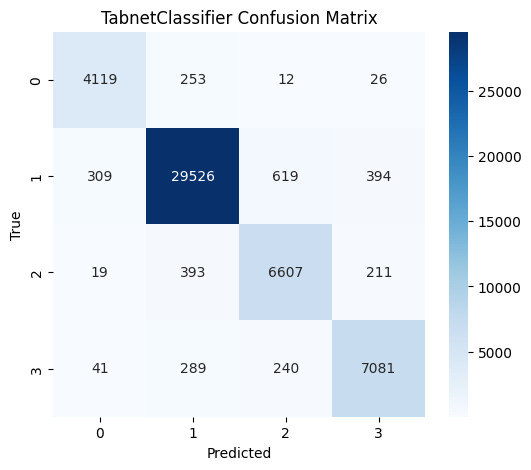

In [ ]:
# Best TabNet Parameters Found:
#   n_d: 64
#   n_steps: 3
#   gamma: 1.4008026020314386
#   lambda_sparse: 4.798433326657619e-05
#   lr: 0.009842269426968387

Tabnet_age = TabNetClassifier(
    n_d= 64,
    n_a= 64,
    n_steps= 3,
    gamma= 1.4008026020314386,
    lambda_sparse= 4.798433326657619e-05,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.009842269426968387),
    mask_type='entmax',
    device_name='cuda',
    verbose=1
)

Tabnet_age.fit(
    X_train=AEF_train_np, y_train=aef_train_np,
    eval_set=[(AEF_val_np, aef_val_np)],
    eval_name=['valid'],
    eval_metric=['logloss'],
    max_epochs=150,
    patience=20,
    batch_size=1024, virtual_batch_size=128,
    weights=smoothed_weight_dict
)

print("\nEvaluating TabNet Model on Test Set...")
tabnet_preds = Tabnet_age.predict(AEF_test_np)

print("\n--- TabNet Classification Report ---")
print(classification_report(aef_test_np, tabnet_preds))

# Plot Confusion Matrices side-by-side
plt.figure(figsize=(6, 5))
cm_xgb = confusion_matrix(aef_test_np, tabnet_preds)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues')
plt.title("TabnetClassifier Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Feature Importance Analyses on Alpha Earth Foundation + Sentinel-2 dataset

## XGBoost SHAP value

In [ ]:
feature_names = AEF_train.columns.tolist()

print("Initializing SHAP TreeExplainer...")
explainer = shap.TreeExplainer(XGBmodel_age)

print("Calculating SHAP values...")
shap_values = explainer.shap_values(AEF_test)

Initializing SHAP TreeExplainer...
Calculating SHAP values...


### Top 20 Features

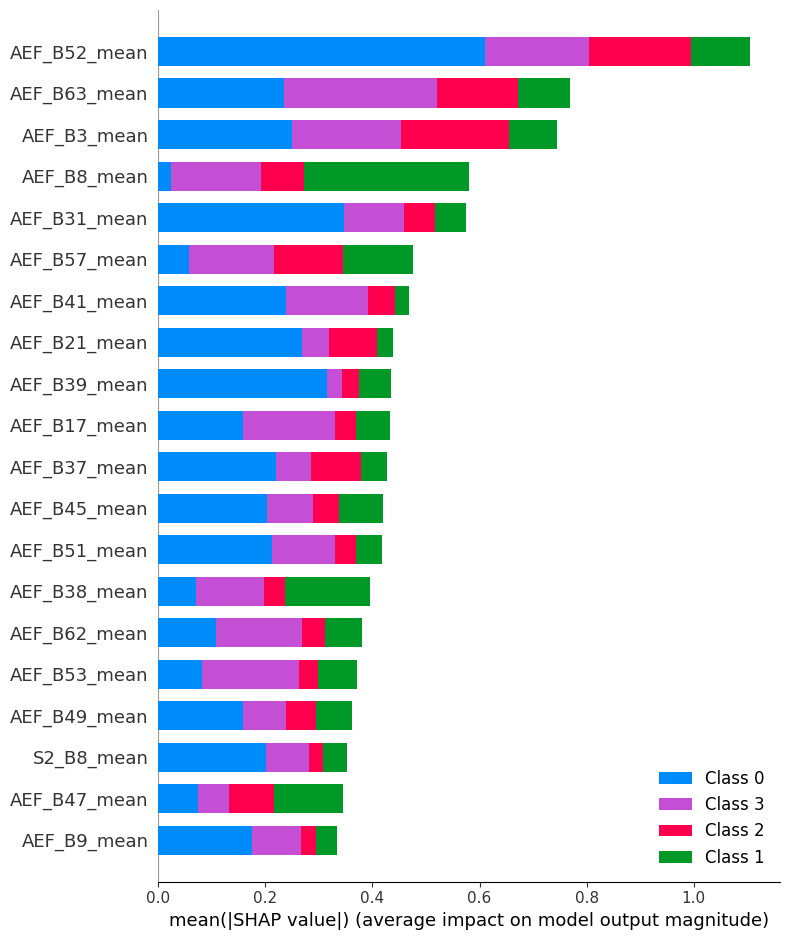

In [ ]:
shap.summary_plot(shap_values, AEF_test, feature_names=feature_names, plot_type="bar")

### Top 100 Features

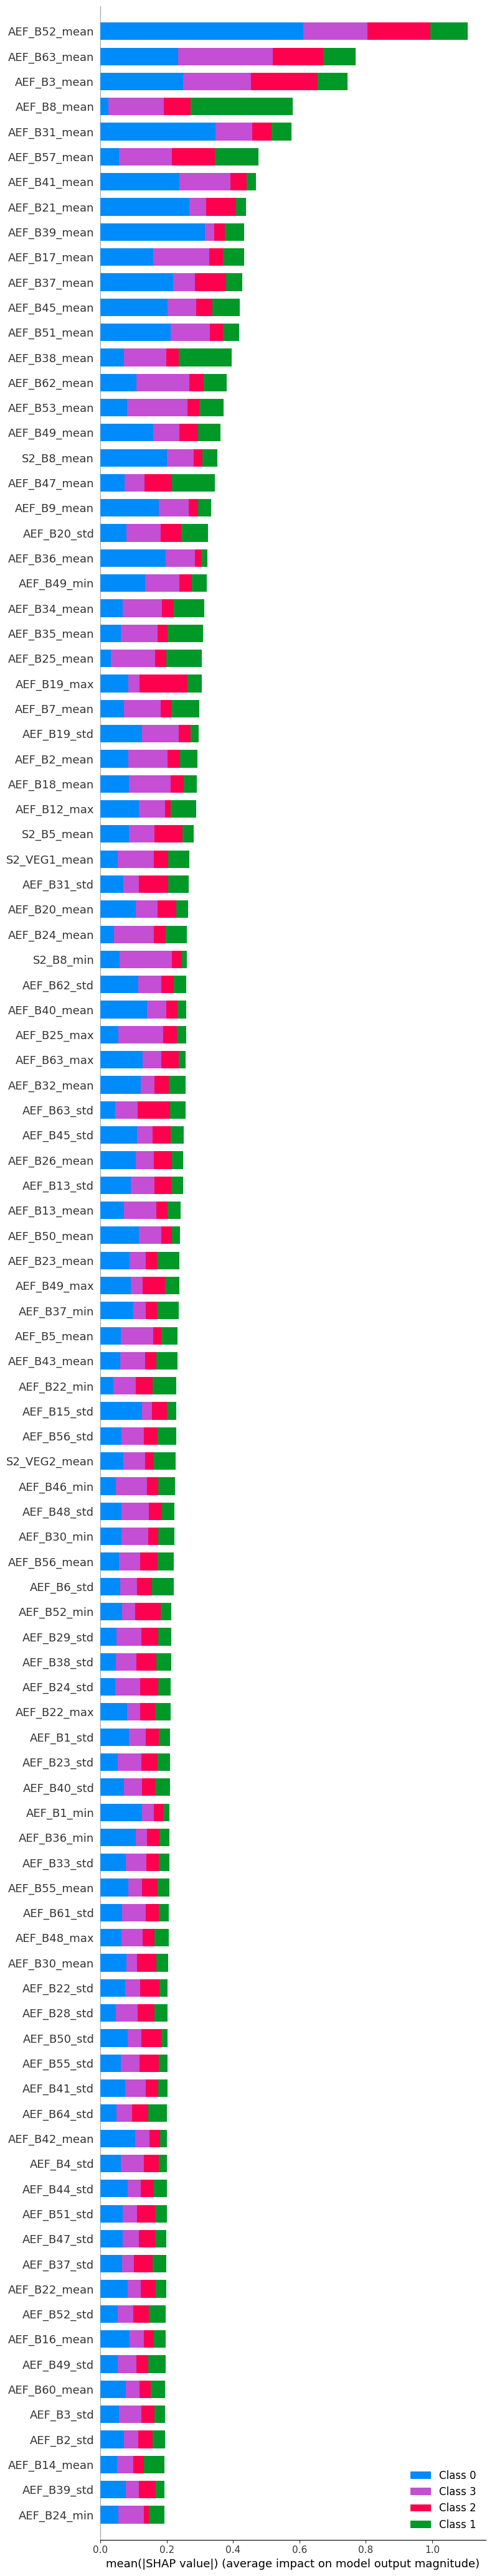

In [ ]:
shap.summary_plot(shap_values, AEF_test, feature_names=feature_names, plot_type="bar", max_display=100)

## Tabnet SHAP value

In [ ]:
import shap

feature_names = AEF_train.columns.tolist()

# Create a small "Test" sample to explain
test_indices = np.random.choice(AEF_test_np.shape[0], 2000, replace=False)
X_test_sample = AEF_test_np[test_indices]

# Initialize the SHAP Explainer
print("Initializing SHAP Explainer...")
explainer = shap.KernelExplainer(Tabnet_age.predict_proba, shap.kmeans(AEF_train_np, 100))

# Calculate SHAP values for the test sample
print("Calculating SHAP values...")
shap_values = explainer.shap_values(X_test_sample)

Initializing SHAP Explainer...
Calculating SHAP values...


  0%|          | 0/2000 [00:00<?, ?it/s]

### Top 20 Features

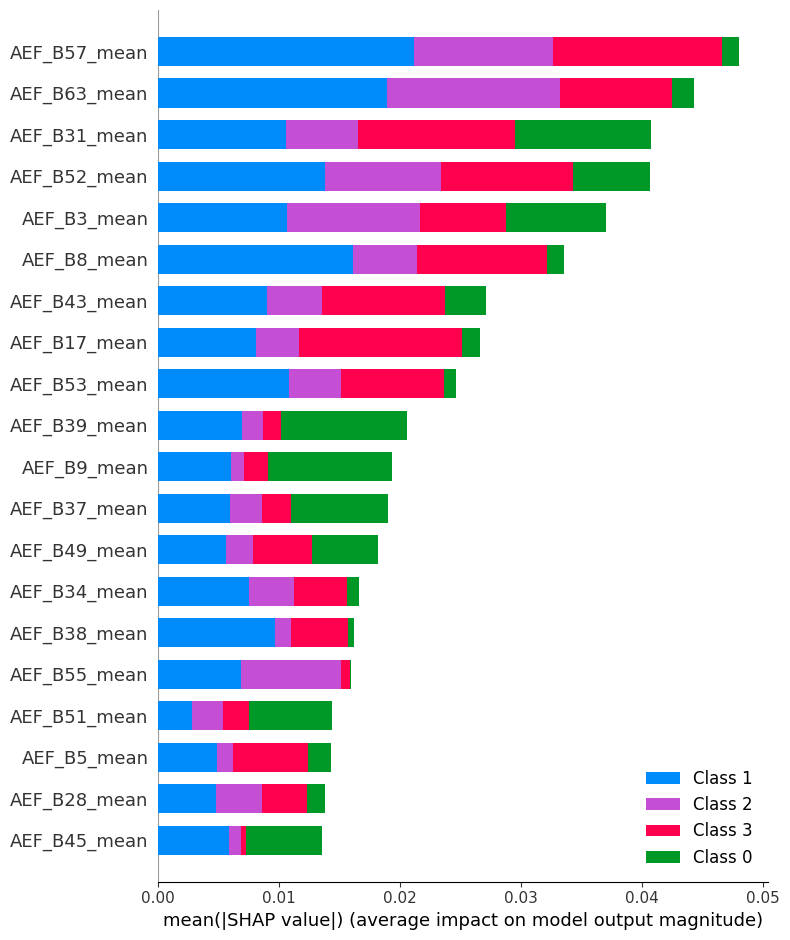

In [ ]:
shap.summary_plot(shap_values, AEF_test_np, feature_names=feature_names, plot_type="bar")

### Top 100 Features

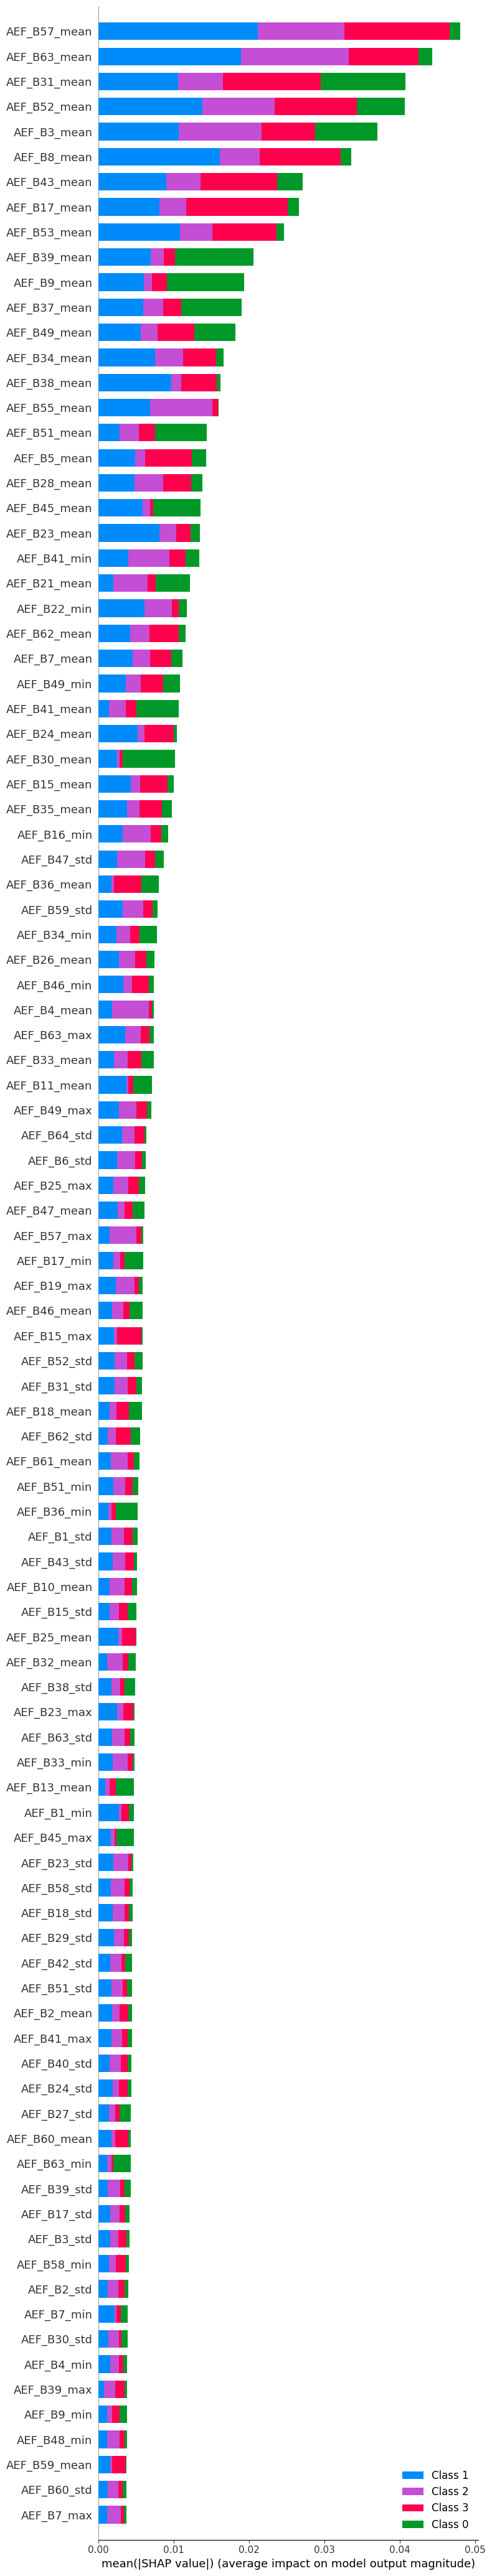

In [ ]:
shap.summary_plot(shap_values, AEF_test_np, feature_names=feature_names, plot_type="bar", max_display = 100)